# Salmon Creek watershed report — Clark County, WA

A **reusable watershed report** for the **Salmon Creek watershed** (Clark County,
WA) — the two WBD sub-watersheds **Upper Salmon Creek** (`170800030102`) and
**Lower Salmon Creek** (`170800030103`), which together drain ~239 km² into the
Columbia through the NHDPlus HR **Lower Columbia** basin (HUC4 `1708`).

This notebook is now a thin driver over **`tools/report_common.py`** — the single
"report-quality" recipe that `tools/build_watershed_report.py` also calls, so the
notebook and the tool can never drift. It reconstructs **year-by-year monthly
streamflow** from real PRISM climate, then reports:

- the watershed map + year-over-year hydrographs,
- a **deep-record trend** (Mann-Kendall + Sen's slope) over the gauge-era record
  (1944–1989) instead of the old OLS-on-10-points,
- a **typical-year** band and the **summer-low** (salmon) trend,
- an honest **model-vs-gauge validation** against USGS gauge **14212000** (Salmon
  Creek near Battle Ground), and
- the **ENSO teleconnection** of peak flow to the ONI index.

The heavy GIS + PRISM + matplotlib work lives in `tools/report_common.py`; the
statistics themselves are the offline `src.flow_metrics` (#48/#49/#53) and
`src.flow_validation` (#50/#51) layer. Like the other `tools/` scripts, this
notebook may import the heavy GIS stack and read real data directly — the
offline-suite discipline only applies to `src/` and `tests/`.
**Kernel:** select **Python (hydro-art)** (the project `.venv`).

> **Model, not gauge — but validated.** Flow is NHDPlus mean-annual discharge
> redistributed by PRISM climate; each reach's annual mean is conserved by
> construction. Section 9 validates it against the real gauge at the gauge's own
> reach (not the basin outlet): the model reproduces gauge *timing and magnitude*
> at Battle Ground — it is climatology-consistent, and here also gauge-comparable.

## 0 · Setup — drive `report_common`

In [1]:
import os
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
# report_common resolves its caches (output/…) + figure dir relative to the repo
# root, exactly as build_watershed_report.py is invoked — so run from there.
os.chdir(REPO)

from IPython.display import Image, display

from tools.report_common import build_report, load_watershed_series
from tools.nwis_gauge import GaugeProvider
from tools.climate_index import ClimateIndexProvider
from tools.historical_flow import DEFAULT_ROOT

# --- the watershed + the record -----------------------------------------
HUC4 = "1708"                                # Lower Columbia (contains Salmon Creek)
HUC12 = ["170800030102", "170800030103"]     # Upper + Lower Salmon Creek
WATERSHED = "Salmon Creek"                    # Clark County, WA
GAUGE = "14212000"                            # USGS Salmon Creek nr Battle Ground, WA
INDEX = "oni"                                 # ENSO ONI (NOAA CPC)

# The gauge's daily-values record is 1943-10..1990-05 (gap 1976..1987), so the
# model-vs-gauge overlap is water years 1944..1989 — the record the deep-trend and
# validation panels run on. (No active gauge covers 2014..2023; 14212000 was
# discontinued in 1990.)
START, END = 1944, 1989

FIG = REPO / "notebooks" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

print(f"repo      : {REPO}")
print(f"watershed : {WATERSHED} (HUC12 {', '.join(HUC12)})")
print(f"parent    : HUC4 {HUC4}")
print(f"record    : {START}-{END}  (gauge {GAUGE} era)")
print(f"PRISM     : {DEFAULT_ROOT}/prism")

repo      : /Users/neilrunde/code/hydro-art
watershed : Salmon Creek (HUC12 170800030102, 170800030103)
parent    : HUC4 1708
record    : 1944-1989  (gauge 14212000 era)
PRISM     : /Volumes/home/data/hydro-art/prism


## 1 · Assemble the watershed series (shared load)

`load_watershed_series` reuses the year-over-year machinery — the HUC12 clip
(`output/_wshed_<tag>_mo1.pkl`) and the whole-basin network cache
(`output/_yoy_net_1708.pkl`) — runs the real PRISM disaggregation over the whole
HUC4 network for correctness, then subsets to the Salmon Creek reaches and picks
the **outlet** as the max-accumulated reach (`src.flow_metrics.outlet_index`).

Reading and disaggregating ~46 years × 12 months of PRISM grids from the NAS
takes a couple of minutes on the first run.

In [2]:
ws = load_watershed_series(HUC4, HUC12, WATERSHED, START, END, root=DEFAULT_ROOT)

from tools.monthly_flow import MONTH_ABBR
print(f"{ws.n} reaches inside {ws.name}")
print(f"outlet reach index : {ws.outlet_idx}")
print(f"network peak month : {MONTH_ABBR[ws.peak_month]}")
print(f"years              : {ws.years[0]}-{ws.years[-1]} ({len(ws.years)} yrs)")

  1708: 205882 reaches x 46 yrs


615 reaches inside Salmon Creek
outlet reach index : 614
network peak month : Dec
years              : 1944-1989 (46 yrs)


## 2 · Gauge + climate index

The USGS gauge monthly means (snapshotted to the NAS for reproducibility) plus the
gauge's coordinates — the coordinates let the validation snap the comparison to the
model reach *at the gauge* rather than the basin outlet. The ONI index (also
snapshotted) drives the ENSO teleconnection.

In [3]:
gp = GaugeProvider(GAUGE, DEFAULT_ROOT)
gauge_obs = gp.monthly_means(START, END)
gauge_loc = gp.location()          # (lat, lon, horizontal-datum code)
print(f"gauge {GAUGE} '{gp.name}'")
print(f"  {len(gauge_obs)} years of observed monthly means over {START}-{END}")
print(f"  site at lat {gauge_loc[0]:.4f}, lon {gauge_loc[1]:.4f} ({gauge_loc[2]})")

index_by_year = ClimateIndexProvider(INDEX, DEFAULT_ROOT).index_by_year(START, END)
print(f"{INDEX.upper()} index: {len(index_by_year)} years")

gauge 14212000 'USGS 14212000 SALMON CREEK NEAR BATTLE GROUND, WA'
  34 years of observed monthly means over 1944-1989
  site at lat 45.7737, lon -122.4457 (NAD83)
ONI index: 40 years


## 3 · Build the full report (one recipe)

`build_report` renders the whole panel set to `notebooks/figures/` and returns a
metrics summary dict. Every panel is driven purely by the offline `src.flow_metrics`
/ `src.flow_validation` layer — the same code the CLI and the web report use. The
sections below display each panel inline with a short reading.

In [4]:
summary = build_report(
    ws,
    gauge_obs=gauge_obs,
    gauge_loc=gauge_loc,
    index_by_year=index_by_year,
    index_name=INDEX.upper(),
    out_dir=FIG,
)

import json
print(json.dumps(summary, indent=2, default=str))

TAG = ws.name.lower().replace(" ", "_")
def show(stem):
    display(Image(filename=str(FIG / f"{TAG}_{stem}.png")))

{
  "watershed": "Salmon Creek",
  "huc4": "1708",
  "years": [
    1944,
    1989
  ],
  "reaches": 615,
  "peak_month": "Dec",
  "trend": "none",
  "tau": -0.017391304347826087,
  "p": 0.8721260229597687,
  "sens_slope": 0.0,
  "low_trend": "none",
  "low_sens_slope": 0.24096158841290977,
  "verdict": "weak",
  "r": 0.7830667028305961,
  "nse": 0.4992621008544349,
  "bias": 18.56564060793806,
  "rmse": 44.85753500191977,
  "overlap_years": [
    1944,
    1945,
    1946,
    1947,
    1948,
    1949,
    1950,
    1951,
    1952,
    1953,
    1954,
    1955,
    1956,
    1957,
    1958,
    1959,
    1960,
    1961,
    1962,
    1963,
    1964,
    1965,
    1966,
    1967,
    1968,
    1969,
    1970,
    1971,
    1972,
    1973,
    1974,
    1975,
    1988,
    1989
  ],
  "reach": 597,
  "reach_dist_m": 10.3,
  "enso_r": 0.16364805475994065,
  "enso_r_lag1": 0.12017702314394038,
  "enso_n": 40
}


## 4 · Where is it? Watershed map

Every Salmon Creek reach colored by hypsometric elevation tint (headwaters bright,
mouth deep-blue). The red dot is the watershed outlet; the yellow triangle is the
model reach at the gauge location.

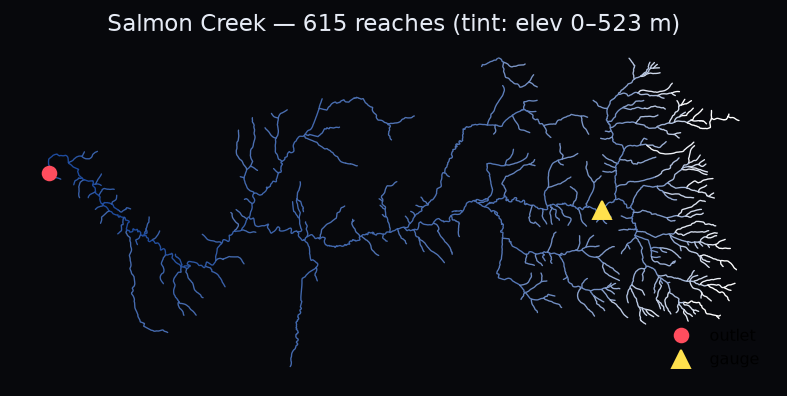

In [5]:
show("map")

## 5 · Year-over-year hydrographs

The outlet hydrograph, one line per year (viridis by year). Winter-wet /
summer-dry Pacific-Northwest seasonality; annual totals are flat by construction,
so the visible variation is the *seasonal* redistribution.

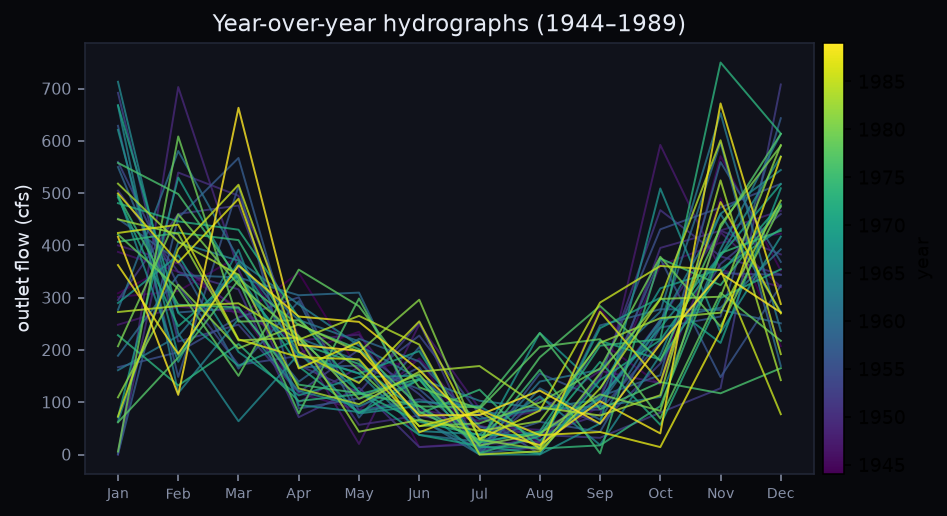

In [6]:
show("hydrographs")

## 6 · Deep record — robust trend (Mann-Kendall + Sen's slope)

The old notebook fit an OLS trend to 10 points. Over the full gauge-era record the
report uses a **non-parametric Mann-Kendall test** (trend direction + significance)
and **Sen's slope** (robust magnitude) — the statistics that make a deep record
meaningful.

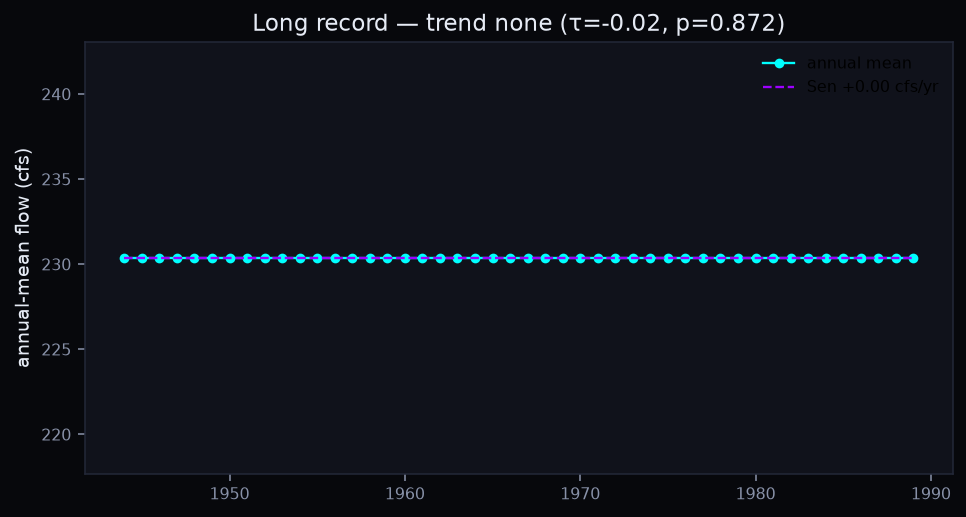

annual-mean trend: {'trend': 'none', 'tau': -0.017391304347826087, 'p': 0.8721260229597687, 'sens_slope': 0.0}


In [7]:
show("long_record")
print("annual-mean trend:",
      {k: summary[k] for k in ("trend", "tau", "p", "sens_slope") if k in summary})

## 7 · Typical year

The mean monthly hydrograph with a P10–P90 across-year band and the
center-of-timing (`src.flow_metrics.center_of_timing`) — the month of 50%
cumulative flow.

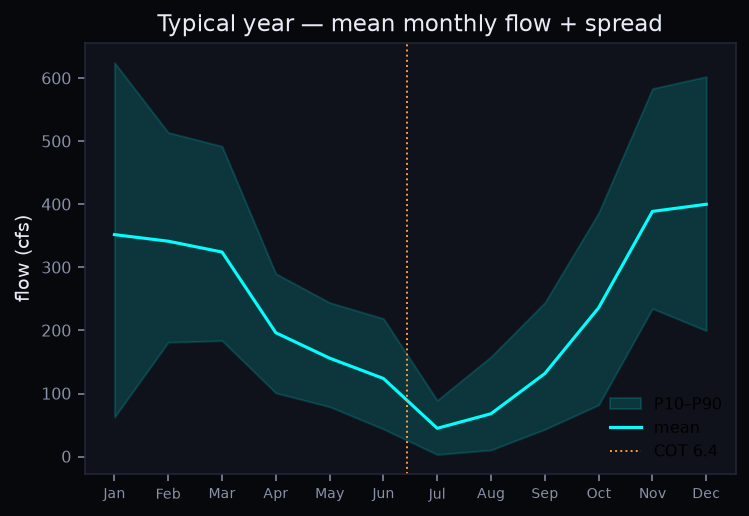

In [8]:
show("typical_year")

## 8 · Summer low flow (salmon / ecological framing)

The summer-low (Jun–Aug minimum) outlet flow per year with its Sen's-slope trend.
Summer low flow — coincident with the warmest stream temperatures — is the
ecological bottleneck for rearing salmonids: a declining trend here is the
signal a habitat report cares about most.

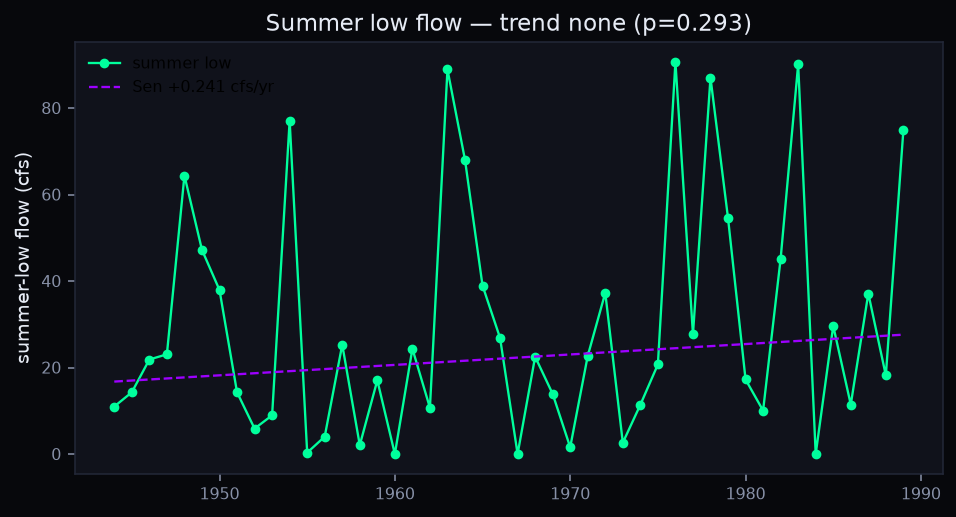

summer-low trend: {'low_trend': 'none', 'low_sens_slope': 0.24096158841290977}


In [9]:
show("low_flow")
print("summer-low trend:",
      {k: summary[k] for k in ("low_trend", "low_sens_slope") if k in summary})

## 9 · Model vs. gauge validation

The honest credibility check. The comparison is snapped to the model reach *at the
gauge* (via `report_common.gauge_reach_index`) rather than the basin outlet — the
outlet is the basin mouth ~23 km downstream at the Lake-River confluence, a ~3.7×
larger drainage than the mid-watershed Battle Ground gauge, so the two were never
apples-to-apples. `src.flow_validation` reports bias / Pearson r / Nash-Sutcliffe /
RMSE with `nan` gauge months skipped (never zero-filled).

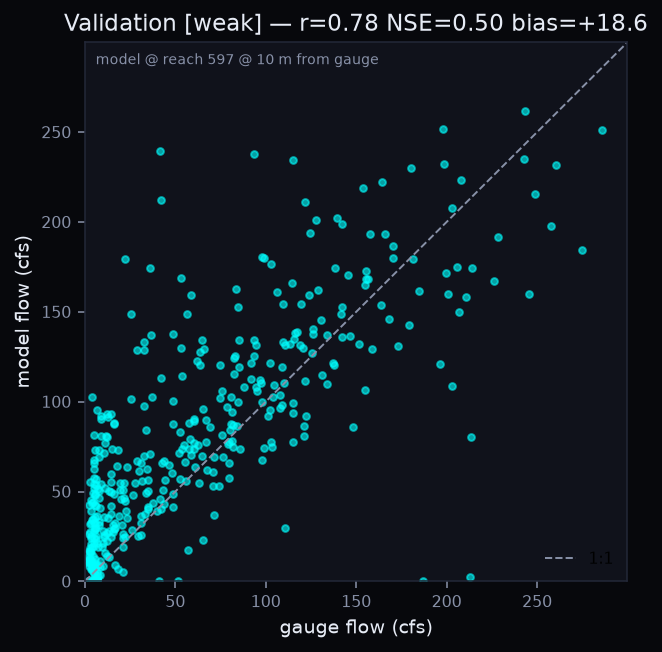

validation: {'verdict': 'weak', 'r': 0.7830667028305961, 'nse': 0.4992621008544349, 'bias': 18.56564060793806, 'rmse': 44.85753500191977, 'reach': 597, 'reach_dist_m': 10.3}


In [10]:
show("validation")
print("validation:",
      {k: summary[k] for k in
       ("verdict", "r", "nse", "bias", "rmse", "reach", "reach_dist_m") if k in summary})

## 10 · ENSO teleconnection

Peak-month flow against the annual ONI index (Pearson r, plus a lag-1 r for a
one-year climate memory). Answers *why* some years run wet or dry — though for a
small coastal-influenced basin the peak-flow ENSO signal is expected to be weak.

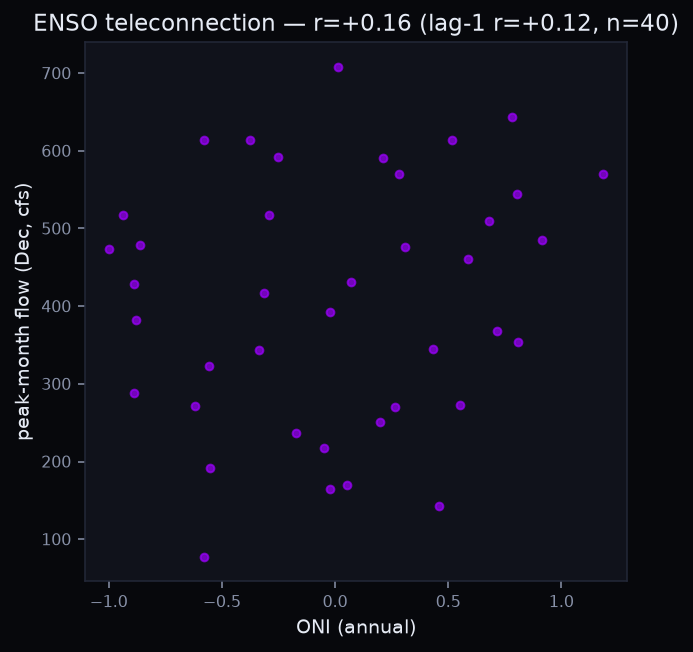

ENSO: {'enso_r': 0.16364805475994065, 'enso_r_lag1': 0.12017702314394038, 'enso_n': 40}


In [11]:
show("enso")
print("ENSO:",
      {k: summary[k] for k in ("enso_r", "enso_r_lag1", "enso_n") if k in summary})

### Notes & how to extend

- **One recipe, no drift.** The notebook now consumes `tools/report_common.py`; the
  identical panels + metrics come from `tools/build_watershed_report.py --huc4 1708
  --huc12 170800030102 170800030103 --name "Salmon Creek" --start 1944 --end 1989
  --gauge 14212000 --index oni`.
- **Try another watershed:** change `HUC12` (and the parent `HUC4`) in the setup
  cell — any WBD `WBDHU12` group inside a locally-staged HUC4 works, e.g. the
  neighbouring `170800030101` (Burnt Bridge Creek) or `170800030105` (Gee Creek).
- **A different record:** point `START`/`END` and `GAUGE` at another era/site; the
  PRISM back-catalog reaches 1895 (stage more with `tools/prism_fetch.py`).
- **Reuse the pieces:** the flow engine is `src.historical_flow` / `src.monthly_flow`;
  the report statistics are `src.flow_metrics` / `src.flow_validation` (pure, offline);
  whole-basin analysis lives in `notebooks/wa_flow_yoy.ipynb`.